# Practical Session 05b &mdash; LDA and QDA from scratch

**Companion to Lecture&nbsp;05.** Second of three notebooks.

| # | Notebook | Topic |
|---|----------|-------|
| 05a | Gaussian naive Bayes | fit a Gaussian per feature per class; the axis-aligned boundary |
| **05b** | **LDA & QDA** | **the full covariance: one shape per class, or one shared (this notebook)** |
| 05c | comparing them | the three models side by side, on real data |

Naive Bayes bought simplicity by forbidding **correlation** between features: its ellipses are always
upright. Real measurements usually move together &mdash; taller people are heavier, a wine's color and
its phenols rise together. **Gaussian discriminant analysis** gives each class a full covariance
matrix, so its ellipse can **tilt**.

That leaves exactly one design choice, and it is the whole lecture:

* give each class its **own** $\Sigma_k$ &mdash; **QDA**, a curved boundary;
* make every class **share** one $\Sigma$ &mdash; **LDA**, a straight one.

> &#11088; **Key idea.** Both come from one score per class,
> $\delta_k(\mathbf{x})=\log\pi_k-\tfrac12\log|\Sigma_k|-\tfrac12(\mathbf{x}-\mu_k)^\top\Sigma_k^{-1}(\mathbf{x}-\mu_k)$,
> and you predict the largest. Share $\Sigma$ and the quadratic piece is the same for every class, so
> it **cancels** &mdash; what is left is a straight line.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_gaussian_classes

use_style("notes")
C0, C1 = "#0072B2", "#D55E00"
rng = np.random.default_rng(0)
print("ready")

ready


## 1. The covariance *is* the shape

A single class is modeled by one multivariate Gaussian. Its density is

$$p(\mathbf{x};\mu,\Sigma)=\frac{1}{(2\pi)^{d/2}\,|\Sigma|^{1/2}}\;
\exp\!\Big(-\tfrac12\,\underbrace{(\mathbf{x}-\mu)^\top\Sigma^{-1}(\mathbf{x}-\mu)}_{D^2(\mathbf{x})}\Big),$$

where $d$ is the number of features. The mean $\mu$ is the **center**; the covariance $\Sigma$ is the
**shape** &mdash; variances on the diagonal, and the off-diagonal entry is the **tilt** that naive Bayes
was not allowed to have. The exponent $D^2$ is the squared **Mahalanobis distance**: how far
$\mathbf{x}$ is from the center, measured in units of the ellipse's own spread.

In code we always compute the **logarithm** of this density. A density in many dimensions is a product
of small numbers and underflows to zero; taking $\log$ turns the product into a sum and the exponential
disappears entirely:

$$\boxed{\;\log p(\mathbf{x};\mu,\Sigma)= -\tfrac12\Big[\;
\underbrace{d\log(2\pi)}_{\text{a constant}}\;+\;
\underbrace{\log|\Sigma|}_{\text{how big the ellipse is}}\;+\;
\underbrace{(\mathbf{x}-\mu)^\top\Sigma^{-1}(\mathbf{x}-\mu)}_{D^2(\mathbf{x})}\;\Big]\;}$$

The function below is exactly those three bracketed terms, in that order.

In [2]:
def mvn_logpdf(X, mu, S):
    "log N(x; mu, S) for every row of X -- the three bracketed terms, in order."
    X = np.atleast_2d(X)
    d = mu.size

    diff = X - mu                             # (x - mu)                for every row
    sol = np.linalg.solve(S, diff.T).T        # Sigma^-1 (x - mu)       -- solve, never invert
    quad = np.einsum("ij,ij->i", diff, sol)   # D^2 = (x-mu)^T Sigma^-1 (x-mu), one per row
    logdet = np.linalg.slogdet(S)[1]          # log|Sigma|              -- stable, no overflow

    return -0.5 * (d * np.log(2 * np.pi) + logdet + quad)

def mvn_pdf(X, mu, S):
    "the density itself -- just exponentiate the log-density"
    return np.exp(mvn_logpdf(X, mu, S))

# sanity check: our from-scratch version against scipy's
from scipy.stats import multivariate_normal
mu_t = np.array([0.3, -0.2]); S_t = np.array([[1.4, 0.6], [0.6, 0.9]])
Xt = rng.normal(size=(6, 2))
print("matches scipy:", np.allclose(mvn_logpdf(Xt, mu_t, S_t),
                                    multivariate_normal(mu_t, S_t).logpdf(Xt)))
print("D^2 of the first 3 rows:", np.einsum("ij,ij->i", Xt[:3] - mu_t,
                                            np.linalg.solve(S_t, (Xt[:3] - mu_t).T).T).round(3))

matches scipy: True
D^2 of the first 3 rows: [0.053 0.122 1.815]


Reading the code against the formula, line by line:

| code | math | why it is written that way |
|---|---|---|
| `diff = X - mu` | $\mathbf{x}-\mu$ | one row per sample, so every point is handled at once |
| `np.linalg.solve(S, diff.T).T` | $\Sigma^{-1}(\mathbf{x}-\mu)$ | **solves** $\Sigma\mathbf{z}=\mathbf{x}-\mu$ instead of building $\Sigma^{-1}$ &mdash; faster and numerically safer |
| `np.einsum("ij,ij->i", diff, sol)` | $D^2=(\mathbf{x}-\mu)^\top\Sigma^{-1}(\mathbf{x}-\mu)$ | a **row-wise** dot product: multiply elementwise, then sum along the feature axis |
| `np.linalg.slogdet(S)[1]` | $\log\lvert\Sigma\rvert$ | returns the log-determinant directly; `np.log(np.linalg.det(S))` would overflow or underflow |
| `-0.5 * (d*log(2pi) + logdet + quad)` | the whole bracket | the three terms above, in the same order |

> &#128161; **Intuition.** Everything the Gaussian knows about a point sits in $D^2$: the only way
> $\mathbf{x}$ enters is through its ellipse-aware distance to the center. Points on the same ellipse
> have the same density, and $\log|\Sigma|$ just penalizes a class for spreading itself thin.

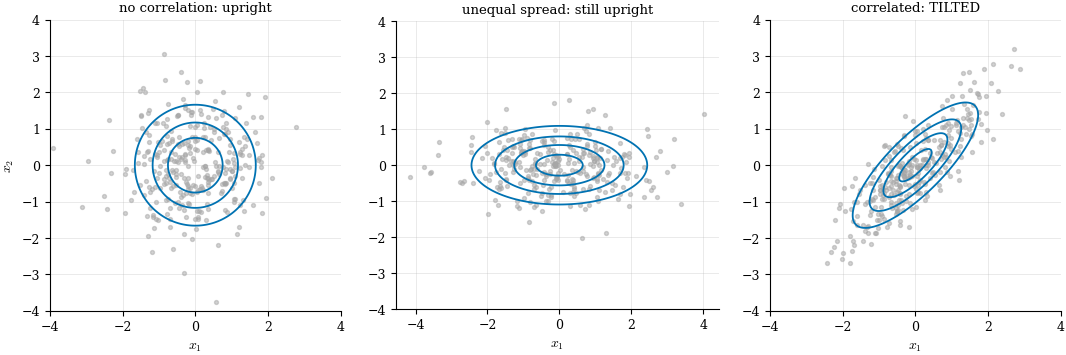

Only the third shape needs an off-diagonal covariance -- and only GDA can fit it.


In [3]:
shapes = [(np.eye(2), "no correlation: upright"),
          (np.diag([2.0, 0.4]), "unequal spread: still upright"),
          (np.array([[1.0, 0.8], [0.8, 1.0]]), "correlated: TILTED")]
gx, gy = np.meshgrid(np.linspace(-4, 4, 220), np.linspace(-4, 4, 220))
G = np.column_stack([gx.ravel(), gy.ravel()]); zero = np.zeros(2)

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
for ax, (S, ttl) in zip(axes, shapes):
    pts = rng.multivariate_normal(zero, S, 320)
    ax.scatter(pts[:, 0], pts[:, 1], s=8, color="0.65", alpha=0.5)
    ax.contour(gx, gy, mvn_pdf(G, zero, S).reshape(gx.shape), levels=4, colors=C0, linewidths=1.3)
    ax.set_title(ttl, fontsize=9.5); ax.set_aspect("equal"); ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.show()
print("Only the third shape needs an off-diagonal covariance -- and only GDA can fit it.")

## 2. Fitting: still just counting and averaging

$$\pi_k=\frac{N_k}{N},\qquad
\mu_k=\frac{1}{N_k}\sum_{i\in k}\mathbf{x}_i,\qquad
\Sigma_k=\frac{1}{N_k}\sum_{i\in k}(\mathbf{x}_i-\mu_k)(\mathbf{x}_i-\mu_k)^\top .$$

LDA additionally **pools** the per-class covariances into a single shared shape,
$\Sigma=\sum_k\frac{N_k}{N}\Sigma_k$.

In [4]:
covs_true = np.stack([np.array([[1.3, 0.7], [0.7, 0.7]]),
                      np.array([[0.7, -0.55], [-0.55, 1.4]])])     # deliberately DIFFERENT shapes
X, y, params = make_gaussian_classes(n=600, seed=0, mus=((-1.4, 0.0), (1.6, 0.4)),
                                     covs=covs_true, priors=[0.5, 0.5])

def fit_gaussians(X, y, ddof=0):
    "one prior, mean and covariance per class (ddof=0 is the MLE)"
    cls = np.unique(y)
    return {"classes": cls,
            "priors": np.array([(y == k).mean() for k in cls]),
            "mus": np.array([X[y == k].mean(axis=0) for k in cls]),
            "covs": np.array([np.cov(X[y == k].T, ddof=ddof) for k in cls])}

P = fit_gaussians(X, y)
S_pooled = np.tensordot(P["priors"], P["covs"], axes=1)

print("estimated means:\n", P["mus"].round(2), "\ntrue means:\n", params["mus"])
print("\nclass 0 covariance:\n", P["covs"][0].round(2))
print("class 1 covariance:\n", P["covs"][1].round(2))
print("\npooled (shared) covariance:\n", S_pooled.round(2))

estimated means:
 [[-1.3   0.04]
 [ 1.5   0.47]] 
true means:
 [[-1.4  0. ]
 [ 1.6  0.4]]

class 0 covariance:
 [[1.21 0.63]
 [0.63 0.63]]
class 1 covariance:
 [[ 0.77 -0.65]
 [-0.65  1.48]]

pooled (shared) covariance:
 [[ 0.97 -0.07]
 [-0.07  1.09]]


## 3. QDA: each class keeps its own shape

Score every class with $\delta_k$ and take the largest. Because each class has its own $\Sigma_k$, the
term $\mathbf{x}^\top\Sigma_k^{-1}\mathbf{x}$ differs between classes and survives &mdash; the boundary
is **quadratic**.

In [5]:
def discriminants(X, P):
    "delta_k(x) for every class"
    return np.column_stack([
        np.log(P["priors"][k]) - 0.5 * np.linalg.slogdet(P["covs"][k])[1]
        - 0.5 * np.einsum("ij,ij->i", X - P["mus"][k],
                          np.linalg.solve(P["covs"][k], (X - P["mus"][k]).T).T)
        for k in range(len(P["classes"]))])

def gda_proba(X, P):
    D = discriminants(X, P); D = D - D.max(axis=1, keepdims=True)
    e = np.exp(D); return e / e.sum(axis=1, keepdims=True)

def gda_predict(X, P):
    return P["classes"][discriminants(X, P).argmax(axis=1)]

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
sk_qda = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X, y)

# NOTE: sklearn's QDA divides the class covariance by N_k - 1 (ddof=1), not N_k
P_sk = fit_gaussians(X, y, ddof=1)
print("our ddof=1 covariance == sklearn's:", np.allclose(P_sk["covs"][0], sk_qda.covariance_[0]))
print("probabilities match sklearn       :", np.allclose(gda_proba(X, P_sk), sk_qda.predict_proba(X)))
print(f"\nQDA accuracy: ours {(gda_predict(X, P_sk) == y).mean():.3f} | sklearn {sk_qda.score(X, y):.3f}")

our ddof=1 covariance == sklearn's: True
probabilities match sklearn       : True

QDA accuracy: ours 0.955 | sklearn 0.955


## 4. LDA: share the shape, and the boundary straightens

Force both classes to use the pooled $\Sigma$. Now $-\tfrac12\mathbf{x}^\top\Sigma^{-1}\mathbf{x}$ and
$-\tfrac12\log|\Sigma|$ are the **same** for both classes, so they disappear from the comparison. What
remains is linear:

$$\delta_1(\mathbf{x})-\delta_0(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b,\qquad
\mathbf{w}=\Sigma^{-1}(\mu_1-\mu_0),\qquad
b=-\tfrac12(\mu_1+\mu_0)^\top\Sigma^{-1}(\mu_1-\mu_0)+\log\tfrac{\pi_1}{\pi_0}.$$

In [6]:
mu0_, mu1_ = P["mus"]; pi0_, pi1_ = P["priors"]

w = np.linalg.solve(S_pooled, mu1_ - mu0_)
b = -0.5 * (mu1_ + mu0_) @ w + np.log(pi1_ / pi0_)
print(f"w = {w.round(4)},  b = {b:.4f}")

# check the cancellation really happened: the score difference IS linear in x
P_shared = {**P, "covs": np.stack([S_pooled, S_pooled])}
D = discriminants(X, P_shared)
print("delta_1 - delta_0 == w.x + b:", np.allclose(D[:, 1] - D[:, 0], X @ w + b))

w = [2.933  0.5677],  b = -0.2583
delta_1 - delta_0 == w.x + b: True


In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(solver="lsqr").fit(X, y)   # lsqr uses the same pooling we did
print("w matches sklearn:", np.allclose(lda.coef_[0], w))
print("b matches sklearn:", np.allclose(lda.intercept_[0], b))

# and the two-class posterior is exactly the logistic function of Session 04
def sigmoid(z):
    z = np.asarray(z, float); out = np.empty_like(z)
    p, n = z >= 0, z < 0
    out[p] = 1 / (1 + np.exp(-z[p])); e = np.exp(z[n]); out[n] = e / (1 + e)
    return out

print("\nsigmoid(w.x + b) == LDA predict_proba:",
      np.allclose(sigmoid(X @ w + b), lda.predict_proba(X)[:, 1]))
print("-> the same S-curve logistic regression fits directly, here DERIVED from two Gaussians.")

w matches sklearn: True
b matches sklearn: True

sigmoid(w.x + b) == LDA predict_proba: True
-> the same S-curve logistic regression fits directly, here DERIVED from two Gaussians.


## 5. The two boundaries, side by side

Same data, same code &mdash; the only difference is whether the classes share a covariance.

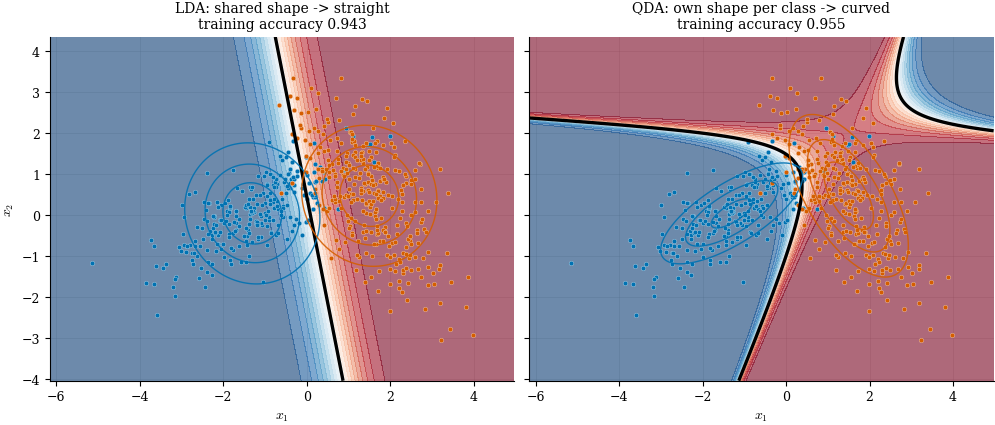

In [8]:
gx, gy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
G = np.column_stack([gx.ravel(), gy.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.3), sharex=True, sharey=True)
for ax, (Pm, ttl) in zip(axes, [(P_shared, "LDA: shared shape -> straight"),
                                (P, "QDA: own shape per class -> curved")]):
    Z = gda_proba(G, Pm)[:, 1].reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(gx, gy, Z, levels=[0.5], colors="black", linewidths=2.4)
    for k, c in ((0, C0), (1, C1)):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=11, color=c, edgecolor="white", linewidth=0.2)
        ax.contour(gx, gy, mvn_pdf(G, Pm["mus"][k], Pm["covs"][k]).reshape(gx.shape),
                   levels=3, colors=c, linewidths=1.0, alpha=0.9)
    acc = (gda_predict(X, Pm) == y).mean()
    ax.set_title(f"{ttl}\ntraining accuracy {acc:.3f}", fontsize=10); ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.show()

> &#128161; **Intuition.** LDA draws **one** ellipse shape and slides it to each class center, so the
> tie between two identical shapes is a straight line. QDA lets the shapes differ, and the tie between
> two *different* ellipses bends &mdash; it can even wrap around the tighter class.

## 6. What the extra flexibility costs

A covariance matrix for $d$ features holds $d(d{+}1)/2$ free numbers. LDA estimates **one**; QDA
estimates **one per class**. More knobs need more data &mdash; the bias-variance trade-off of
Session&nbsp;03, in Gaussian clothing.

d =  2 features, 3 classes:  LDA    3 covariance numbers | QDA     9
d =  5 features, 3 classes:  LDA   15 covariance numbers | QDA    45
d = 13 features, 3 classes:  LDA   91 covariance numbers | QDA   273
d = 30 features, 3 classes:  LDA  465 covariance numbers | QDA  1395


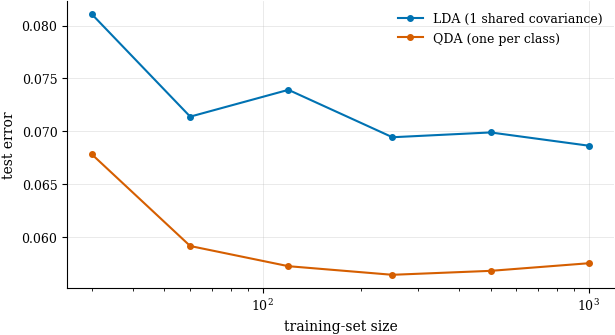

Here the classes really do have different shapes, so QDA's flexibility pays off.


In [9]:
for d in (2, 5, 13, 30):
    per_cov = d * (d + 1) // 2
    print(f"d = {d:2d} features, 3 classes:  LDA {per_cov:4d} covariance numbers | "
          f"QDA {3 * per_cov:5d}")

# how much data does each need? test error against training-set size
sizes = [30, 60, 120, 250, 500, 1000]
Xb, yb, _ = make_gaussian_classes(n=6000, seed=11, mus=((-1.4, 0.0), (1.6, 0.4)), covs=covs_true)
Xte_, yte_ = Xb[3000:], yb[3000:]
err = {"LDA": [], "QDA": []}
for n in sizes:
    eL, eQ = [], []
    for r in range(25):
        idx = np.random.default_rng(100 * n + r).choice(3000, n, replace=False)
        Ps = fit_gaussians(Xb[idx], yb[idx])
        Sp = np.tensordot(Ps["priors"], Ps["covs"], axes=1)
        eL.append((gda_predict(Xte_, {**Ps, "covs": np.stack([Sp, Sp])}) != yte_).mean())
        eQ.append((gda_predict(Xte_, Ps) != yte_).mean())
    err["LDA"].append(np.mean(eL)); err["QDA"].append(np.mean(eQ))

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.semilogx(sizes, err["LDA"], "-o", ms=4, color=C0, label="LDA (1 shared covariance)")
ax.semilogx(sizes, err["QDA"], "-o", ms=4, color=C1, label="QDA (one per class)")
ax.set_xlabel("training-set size"); ax.set_ylabel("test error"); ax.legend(fontsize=9)
plt.show()
print("Here the classes really do have different shapes, so QDA's flexibility pays off.")

## Recap & exercises

**Recap.**
* A full **covariance** lets a class ellipse **tilt** &mdash; the correlation naive Bayes had to ignore.
* Fitting is still counting and averaging: a prior, a mean and a covariance per class; LDA additionally
  **pools** the covariances into one shared shape.
* One score does both methods:
  $\delta_k=\log\pi_k-\tfrac12\log|\Sigma_k|-\tfrac12(\mathbf{x}-\mu_k)^\top\Sigma_k^{-1}(\mathbf{x}-\mu_k)$.
* **QDA** (own $\Sigma_k$) keeps the quadratic term $\Rightarrow$ a **curved** boundary;
  **LDA** (shared $\Sigma$) cancels it $\Rightarrow$ a **straight** boundary with
  $\mathbf{w}=\Sigma^{-1}(\mu_1-\mu_0)$.
* The LDA posterior is exactly $\sigma(\mathbf{w}^\top\mathbf{x}+b)$ &mdash; the logistic model of
  Session&nbsp;04, *derived* rather than fitted.
* Both matched scikit-learn (watch the convention: sklearn's QDA divides by $N_k-1$).
* QDA's extra covariances must be paid for in data.

**Exercises.**
1. Make both true covariances equal and refit. Does QDA's boundary straighten out, and do the two
   learning curves converge?
2. Set unequal priors ($\pi_1=0.2$) and check that $b$ moves by exactly $\log(\pi_1/\pi_0)$.
3. Raise the dimension to $d=8$ with only $n=100$ samples. Which method degrades first, and does the
   $d(d{+}1)/2$ count explain it?
4. Replace $\Sigma_k$ with $(1-\lambda)\Sigma_k+\lambda I$ ("regularized QDA") and sweep $\lambda$ from
   0 to 1. What does it interpolate between?
5. Feed a naive-Bayes-style **diagonal** covariance into `discriminants`. Do you recover the notebook
   05a classifier?

*Next:* **05c &mdash; comparing them**: naive Bayes, LDA and QDA side by side on real data, and a
practical rule for choosing.